## `nz.ipynb`
-------------

The goal of this notebook is to combine the measurements from auto-correlations and cross-correlation.

In [20]:
import numpy as np
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import json
import scipy.interpolate as interp

from datetime import datetime
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson
from pycorr import TwoPointEstimator

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

ROOT = cf.get_base_dir()

In [ ]:
CORR_ROOT = ROOT / "src" / "statistics" / "outputs"
bins_hsc = np.arange(0.3, 1.8, 0.3)

RESULTS_ROOT = ROOT / "results"
Path(RESULTS_ROOT).mkdir(parents=True, exist_ok=True)

markers = ["x", "s", "^", "D"]
linestyles = ["-", "--", "-.", ":"]
colormaps = [plt.get_cmap(c) for c in ["Reds", "Blues", "Greens", "Purples"]]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
tracer_trad = {
    "BGS_ANY": "BGS",
    "LRG": "LRG",
    "ELGnotqso": "ELG",
    "QSO": "QSO",
}
stem = "dr2"
path_dictionary = {
    "HSC": CORR_ROOT / "v12_correction" / f"autos_HSC",  # unused in practice
    "DESI_NGC": CORR_ROOT / stem / f"autos_NGC",
    "DESI_SGC": CORR_ROOT / stem / f"autos_SGC",
    "DESIxHSC": CORR_ROOT / stem / f"cross",
}
fr = cf.CorrFileReader(path_dictionary["DESIxHSC"])

do_phot_correction = True
do_spec_correction = True

scale_cut = [0.3, 3]
version = "vtest"

print(f"Scale cut: {scale_cut[0]} - {scale_cut[1]} Mpc/h")

# which tracers to use in inference
tomo_to_tracer = {
    1: ["BGS_ANY", "LRG"],  # 'ELG_LOPnotqso'
    2: ["BGS_ANY", "LRG"],  # 'ELG_LOPnotqso' "QSO"
    3: ["LRG", "ELGnotqso"],
    4: ["LRG", "ELGnotqso"],
}
# which patches to use in inference
patches = [1, 2, 3, 4]

Scale cut: 0.3 - 3 Mpc/h


In [22]:
## precompute w_dm
importlib.reload(inference)
bins_z_spectro = inference._get_fine_redshift_bins(fr=fr, tracer="Merged")
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array(
    [
        ct.w_dm(
            rp_vals=rp_wdm,
            z=z,  # compute w_dm centered at redshift z
            integrate=True,  # integrate over the scale cuts provided (so on rp_vals)
        )
        for z in vals_z_wdm
    ]
)
wdm_interpolator = interp.interp1d(
    vals_z_wdm, wdm_values, bounds_error=False, fill_value="extrapolate"
)

In [23]:
# estimated runtime on NERSC ~5minutes
# this is for npz_cross, we merge directly on tracers due to amplitude differences.
importlib.reload(inference)
for tomo in [1, 2, 3, 4]:
    if tomo in [1, 2]:
        stem = "dr1"
    else:
        stem = "dr2"
    print(f"=== Tomographic bin {tomo} ===")
    path_dictionary = {
        "HSC": CORR_ROOT / "v12_correction" / f"autos_HSC",  # unused in practice
        "DESI_NGC": CORR_ROOT / stem / f"autos_NGC",
        "DESI_SGC": CORR_ROOT / stem / f"autos_SGC",
        "DESIxHSC": CORR_ROOT / stem / f"cross",
        "MergedxMerged": CORR_ROOT / f"merged_{stem}_{version}",
        "MergedxHSC": CORR_ROOT / f"merged_{stem}_{version}",
    }
    inference.merge_estimators(
        path_dictionary=path_dictionary,
        which_tomo=[tomo],
        outdir=path_dictionary["MergedxMerged"],  # where to save results
        which_tracers=tomo_to_tracer[tomo],
    )

=== Tomographic bin 1 ===
Processing redshift bin 0 (Completion : 4.76%)


Processing redshift bin 2 (Completion : 14.29%)
Processing redshift bin 4 (Completion : 23.81%)
Processing redshift bin 6 (Completion : 33.33%)
Processing redshift bin 8 (Completion : 42.86%)
Processing redshift bin 10 (Completion : 52.38%)
Processing redshift bin 12 (Completion : 61.90%)
Processing redshift bin 14 (Completion : 71.43%)
Processing redshift bin 16 (Completion : 80.95%)
Processing redshift bin 18 (Completion : 90.48%)
Processing redshift bin 20 (Completion : 100.00%)
Saved cross-correlation estimator to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_dr1_vtest/MergedxHSC/MergedxHSC_b1x1_b2x1.npy
Saved auto-correlation estimator to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_dr1_vtest/MergedxMerged/MergedxMerged_b1x1_b2x1.npy
Saved cross-correlation estimator to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_dr1_vtest/MergedxHSC/MergedxHSC_b1x2_b2x1.npy
Saved auto

In [24]:
importlib.reload(inference)
importlib.reload(ct)
print("\nScale cuts : ", scale_cut, "\n")

npzs = [
    {k: [] for k in [1, 2, 3, 4]} for _ in range(4)
]  # no correction, only spec, both spec and bias, both spec & bias & mag
npz_errs = [{k: [] for k in [1, 2, 3, 4]} for _ in range(4)]
zvals = [{k: [] for k in [1, 2, 3, 4]} for _ in range(4)]

for ic, condition in enumerate(
    [
        (False, False, False),  # no correction
        (False, True, False),  # only spec correction
        (True, True, False),  # with bias and spec correction
        (True, True, True),  # with magnification
    ]
):
    do_phot_correction, do_spec_correction, do_mag = condition
    for tomo in [1, 2, 3, 4]:
        stem = "dr2" if tomo == 3 or tomo == 4 else "dr1"
        path_dictionary = {
            "HSC": CORR_ROOT / "v12_correction" / f"autos_HSC",  # unused in practice
            "DESI_NGC": CORR_ROOT / stem / f"autos_NGC",
            "DESI_SGC": CORR_ROOT / stem / f"autos_SGC",
            "DESIxHSC": CORR_ROOT / stem / f"cross",
            "MergedxMerged": CORR_ROOT / f"merged_{stem}_{version}",
            "MergedxHSC": CORR_ROOT / f"merged_{stem}_{version}",
        }
        fr = cf.CorrFileReader(path_dictionary["DESIxHSC"])
        if condition == (False, False, False):
            # we fuse estimators for the no correction case because of amplitude differences for each tracer...
            # just makes it easier to compare. These are made with the "merged" files
            meas = inference.full_npz_tomo(
                path_dictionary=path_dictionary,
                do_phot_correction=do_phot_correction,
                do_spec_correction=do_spec_correction,
                scale_cuts=scale_cut,
                tomo_bin=tomo,
                tracer=tomo_to_tracer[tomo], 
                which_patches=None,  # they have already been fused together
                precomp_wdm=wdm_interpolator,
                mode="Merged",
            )
            npzs[ic][tomo].append(meas[0])
            npz_errs[ic][tomo].append(meas[1])
            zbins = inference._get_fine_redshift_bins(fr, tracer=tomo_to_tracer[tomo])
            _zvals = (zbins[:-1] + zbins[1:]) / 2
            zvals[ic][tomo].append(_zvals)
            assert len(meas[0]) == len(_zvals)
            print(meas[0], _zvals, "Merged")
        else:
            for ind, tracer in enumerate(tomo_to_tracer[tomo]):

                zbins = fr.get_bins(tracer)
                _zvals = (zbins[:-1] + zbins[1:]) / 2
                meas = inference.full_npz_tomo(
                    path_dictionary=path_dictionary,
                    do_phot_correction=do_phot_correction,
                    do_spec_correction=do_spec_correction,
                    scale_cuts=scale_cut,
                    tomo_bin=tomo,
                    tracer=tracer,
                    which_patches=patches,
                    precomp_wdm=wdm_interpolator,
                )
                if do_mag == True:
                    _npz, _npz_err, wdm, Mag, dMag = ct.solve_magnification(
                        meas=meas,
                        tracer=tracer,
                        tomo_bin=tomo,
                        scale_cut=scale_cut,
                        zvalues=_zvals,
                        return_matrices=True,
                    )
                    meas = (_npz, _npz_err)

                zvals[ic][tomo].append(_zvals)
                npzs[ic][tomo].append(meas[0])
                npz_errs[ic][tomo].append(meas[1])
                assert len(meas[0]) == len(_zvals)


Scale cuts :  [0.3, 3] 

Using merged method for tracer ['BGS_ANY', 'LRG'] and tomo bin 1.
[-0.01719671 -0.00089597  0.03745487  0.02955107  0.05279     0.10358466
  0.16471537  0.17873603  0.26047612  0.29513405  0.40703009  0.27042547
  0.1193858   0.03096448  0.01618509 -0.00403075  0.01855159  0.05853609
  0.0050004   0.03320561  0.09790208] [0.025 0.075 0.125 0.175 0.225 0.275 0.325 0.375 0.425 0.475 0.525 0.575
 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975 1.025] Merged
Using merged method for tracer ['BGS_ANY', 'LRG'] and tomo bin 2.
[-0.00989832 -0.00929791  0.03634942 -0.00603624 -0.01381432 -0.00564261
 -0.01632963 -0.00574009  0.00947238  0.00849305  0.02296525  0.15398958
  0.29263071  0.34742445  0.40207289  0.40433909  0.42965974  0.36237966
  0.24182331  0.14391928  0.09262137] [0.025 0.075 0.125 0.175 0.225 0.275 0.325 0.375 0.425 0.475 0.525 0.575
 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975 1.025] Merged
Using merged method for tracer ['LRG', 'ELGnotqso'] and 

In [25]:
RESULTS_ROOT = ROOT / "results"
Path(RESULTS_ROOT).mkdir(parents=True, exist_ok=True)
data_rows = []

for tomo in [1, 2, 3, 4]:
    # --- "Merged" cases (cross)
    z_vals_cross = zvals[0][tomo][0]
    nz_cross = npzs[0][tomo][0]
    nz_cross_err = npz_errs[0][tomo][0]

    for j in range(len(z_vals_cross)):
        data_rows.append(
            {
                "tomo_bin": tomo,
                "tracer": "Merged",
                "redshift": z_vals_cross[j],
                "npz_cross": nz_cross[j],
                "npz_cross_err": nz_cross_err[j],
                "npz_bs_bp": None,
                "npz_bs_bp_err": None,
                "npz_bs_bp_mag": None,
                "npz_bs_bp_mag_err": None,
            }
        )

    # --- per-tracer cases (bs_bp & bs_bp_mag)
    for i, tracer in enumerate(tomo_to_tracer[tomo]):
        z_vals_bs = zvals[1][tomo][i]
        nz_bs = npzs[1][tomo][i]
        nz_bs_err = npz_errs[1][tomo][i]

        z_vals_bp = zvals[2][tomo][i]
        nz_bs_bp = npzs[2][tomo][i]
        nz_bs_bp_err = npz_errs[2][tomo][i]

        z_vals_bp_mag = zvals[3][tomo][i]
        nz_bs_bp_mag = npzs[3][tomo][i]
        nz_bs_bp_mag_err = npz_errs[3][tomo][i]

        # sanity check: bp and bp_mag z-grids should match
        assert np.allclose(z_vals_bp, z_vals_bp_mag)

        for j in range(len(z_vals_bp)):
            data_rows.append(
                {
                    "tomo_bin": tomo,
                    "tracer": tracer,
                    "redshift": z_vals_bp[j],
                    "npz_cross": None,
                    "npz_cross_err": None,
                    "npz_bs": nz_bs[j],
                    "npz_bs_err": nz_bs_err[j],
                    "npz_bs_bp": nz_bs_bp[j],
                    "npz_bs_bp_err": nz_bs_bp_err[j],
                    "npz_bs_bp_mag": nz_bs_bp_mag[j],
                    "npz_bs_bp_mag_err": nz_bs_bp_mag_err[j],
                }
            )

df = pd.DataFrame(data_rows)
patches = [1, 2, 3, 4]

path_dict_metadata = {}
for tomo in [1, 2, 3, 4]:
    stem = "dr2" if tomo == 3 or tomo == 4 else "dr1"
    path_dict_metadata[f"tomo_{tomo}"] = {
        "HSC": str(CORR_ROOT / "v12_correction" / f"autos_HSC"),
        "DESI_NGC": str(CORR_ROOT / stem / f"autos_NGC"),
        "DESI_SGC": str(CORR_ROOT / stem / f"autos_SGC"),
        "DESIxHSC": str(CORR_ROOT / stem / f"cross"),
        "stem": stem,
    }

metadata = {
    "scale_cuts": scale_cut,
    "patches": patches,
    "path_dictionaries": path_dict_metadata,
    "creation_date": datetime.now().isoformat(),
    "description": "Magnification corrected and raw n(z) measurements for DESI tracers across HSC tomographic bins",
    "tracers_by_tomo": tomo_to_tracer,
}

output_file = (
    Path(RESULTS_ROOT) / f"nz_res_{scale_cut[0]}_{scale_cut[1]}_{version}.parquet"
)
df.to_parquet(output_file, index=False)

metadata_file = (
    Path(RESULTS_ROOT) / f"nz_res_metadata_{scale_cut[0]}_{scale_cut[1]}_{version}.json"
)
with open(metadata_file, "w") as f:
    json.dump(metadata, f, indent=2)

print(df.head(10))

   tomo_bin  tracer  redshift  npz_cross  npz_cross_err  npz_bs_bp  \
0         1  Merged     0.025  -0.017197       0.023855        NaN   
1         1  Merged     0.075  -0.000896       0.019116        NaN   
2         1  Merged     0.125   0.037455       0.019121        NaN   
3         1  Merged     0.175   0.029551       0.017076        NaN   
4         1  Merged     0.225   0.052790       0.020306        NaN   
5         1  Merged     0.275   0.103585       0.023812        NaN   
6         1  Merged     0.325   0.164715       0.025396        NaN   
7         1  Merged     0.375   0.178736       0.022882        NaN   
8         1  Merged     0.425   0.260476       0.022416        NaN   
9         1  Merged     0.475   0.295134       0.027111        NaN   

   npz_bs_bp_err  npz_bs_bp_mag  npz_bs_bp_mag_err  npz_bs  npz_bs_err  
0            NaN            NaN                NaN     NaN         NaN  
1            NaN            NaN                NaN     NaN         NaN  
2         

In [26]:
print(f"Scale cut {scale_cut[0]} - {scale_cut[1]} Mpc/h results saved to {output_file}")
data = pd.read_parquet(
    f"{RESULTS_ROOT}/nz_res_{scale_cut[0]}_{scale_cut[1]}_{version}.parquet"
)
print(data.columns)

Scale cut 0.3 - 3 Mpc/h results saved to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/nz_res_0.3_3_vtest.parquet
Index(['tomo_bin', 'tracer', 'redshift', 'npz_cross', 'npz_cross_err',
       'npz_bs_bp', 'npz_bs_bp_err', 'npz_bs_bp_mag', 'npz_bs_bp_mag_err',
       'npz_bs', 'npz_bs_err'],
      dtype='object')


In [27]:
importlib.reload(inference)
merged = {"1": {}, "2": {}, "3": {}, "4": {}}
names = ["npz_cross", "npz_bs", "npz_bs_bp", "npz_bs_bp_mag"]

In [28]:
for name in names:
    for tomo in [1, 2, 3, 4]:
        data_tomo = data[data["tomo_bin"] == tomo]
        tracers = list(set(data_tomo["tracer"]))
        zv = [data_tomo["redshift"][data_tomo["tracer"] == t].values for t in tracers]
        _npz = [data_tomo[name][data_tomo["tracer"] == t].values for t in tracers]
        _npz_err = [
            data_tomo[name + "_err"][data_tomo["tracer"] == t].values for t in tracers
        ]
        print(name, tomo, tracers, zv)

        zmt_raw, npmt, npmt_err = inference.merge_results(zv, _npz, _npz_err)
        merged[str(tomo)].update(
            {
                name + "_z": zmt_raw,
                name: npmt,
                name + "_err": npmt_err,
            }
        )
    merged[str(tomo)]["z"] = zmt_raw
save_dict = {
    f"{tomo}/{k}": np.array(v) for tomo, d in merged.items() for k, v in d.items()
}

np.savez_compressed(
    f"{RESULTS_ROOT}/merged_res_{scale_cut[0]}_{scale_cut[1]}_{version}.npz",
    **save_dict,
)

npz_cross 1 ['Merged', 'LRG', 'BGS_ANY'] [array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425,
       0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875,
       0.925, 0.975, 1.025]), array([0.425, 0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825,
       0.875, 0.925, 0.975, 1.025, 1.075]), array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425,
       0.475])]
npz_cross 2 ['Merged', 'LRG', 'BGS_ANY'] [array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425,
       0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875,
       0.925, 0.975, 1.025]), array([0.425, 0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825,
       0.875, 0.925, 0.975, 1.025, 1.075]), array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425,
       0.475])]
npz_cross 3 ['ELGnotqso', 'Merged', 'LRG'] [array([0.725, 0.775, 0.825, 0.875, 0.925, 0.975, 1.025, 1.075, 1.125,
       1.175, 1.225, 1.275, 1.325, 1.375, 1.425, 1.475, 1.525,

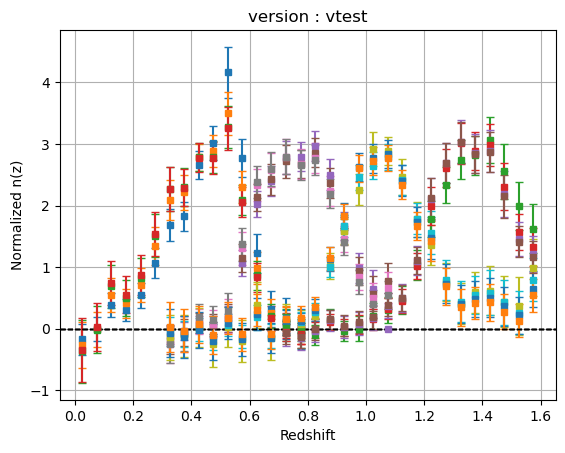

In [30]:
# renormalization and plotting
tbl = np.load(f"{RESULTS_ROOT}/merged_res_{scale_cut[0]}_{scale_cut[1]}_{version}.npz")
tomo_bins = [1, 2, 3, 4]
bounds = {"1": (0, 0.8), "2": (0.3, 1.3), "3": (0.3, 2.1), "4": (0.7, 2.1)}
names = ["npz_cross", "npz_bs", "npz_bs_bp", "npz_bs_bp_mag"]
norm_tbl = {}
for tomo in tomo_bins:
    for na in names:
        zn = tbl[f"{tomo}/{na}_z"]
        z_mask = (zn >= bounds[str(tomo)][0]) & (zn <= bounds[str(tomo)][1])
        np_z = tbl[f"{tomo}/{na}"][z_mask]
        np_z_err = tbl[f"{tomo}/{na}_err"][z_mask]

        # one has to renormalize by the integral over the range for cases
        amplitude = np.trapezoid(np_z, zn[z_mask])

        norm_tbl[f"{tomo}/{na}_z"] = zn[z_mask]
        norm_tbl[f"{tomo}/{na}"] = np_z / amplitude
        norm_tbl[f"{tomo}/{na}_err"] = np_z_err / amplitude

        plt.errorbar(
            zn[z_mask],
            norm_tbl[f"{tomo}/{na}"],
            norm_tbl[f"{tomo}/{na}_err"],
            capsize=3,
            label=f"n(z) {na}",
            linestyle="",
            marker="s",
            ms=4,
        )
    plt.axhline(0, color="k", linestyle="--", linewidth=1)
    plt.grid(True)
    plt.xlabel("Redshift")
    plt.ylabel("Normalized n(z)")

if len(tomo_bins) == 1:
    plt.legend()
plt.title(f"version : {version}")
np.savez_compressed(
    f"{RESULTS_ROOT}/merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_{version}.npz",
    **norm_tbl,
)